In [99]:
import sys
from pathlib import Path 
import pickle
import random

BEAM_WIDTH = 1
HW = 3
N = 9
M = 20
K = 81
INF = 10**18
MOD = 998244353
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False

def fastcopy(obj):
    return pickle.loads(pickle.dumps(obj, -1))

def debug_print(*args, **kwargs):
    if not ONLINE_JUDGE:
        print(*args, **kwargs)

In [100]:
class Env:
    def __init__(self, input_txt_path: Path):
        self.grid, self.stamps = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        grid = []
        for i in range(1, 1+N):
            d = list(map(int, lines[i].split()))
            grid.append(d)
        stamps = []
        for i in range(1+N, 1+N+M*HW, 3):
            tmp_stamp = []
            for j in range(HW):
                d = list(map(int, lines[i+j].split()))
                tmp_stamp.append(d)
            stamps.append(tmp_stamp)
        return grid, stamps

    def print_grid(self):
        for d in self.grid:
            print(d)
    
    def pring_stamps(self):
        for s in self.stamps:
            for d in s:
                print(d)
            print()

In [101]:
def evaluate_score(grid: list[list[int]]) -> int:
    s = 0
    for h in range(N):
        for w in range(N):
            s += grid[h][w] % MOD
    return s

In [102]:
def step(grid: list[list[int]], stamps):
    score = evaluate_score(grid)
    ans = None
    for m1 in range(M):
        for h1 in range(N-3):
            for w1 in range(N-3):
                now_grid = fastcopy(grid)
                for h in range(HW):
                    for w in range(HW):
                        now_grid[h1+h][w1+w] = (now_grid[h1+h][w1+w] + stamps[m1][h][w]) % MOD
                tmp_score = evaluate_score(now_grid)
                if tmp_score > score:
                    score = tmp_score
                    ans = (m1, h1, w1)
    return ans

In [103]:
class API:
    def __init__(self, n, env: Env):
        self.iter = 0
        self.n = n
        self.env = env

    def init(self):
        self.iter = 0

    def step(self, grid_and_paths):
        grid, paths = grid_and_paths
        for m1 in range(M):
            for h1 in range(N-3):
                for w1 in range(N-3):
                    now_grid = fastcopy(grid)
                    for h in range(HW):
                        for w in range(HW):
                            now_grid[h1+h][w1+w] = (now_grid[h1+h][w1+w] + self.env.stamps[m1][h][w]) % MOD
                    yield now_grid, paths + [(m1, h1, w1)]

    def score(self, grid_and_paths):
        grid, paths = grid_and_paths
        """total distance of path"""
        return evaluate_score(grid)

    def count(self):
        self.iter += 1

    def terminate(self):
        return self.iter >= self.n

In [104]:
from heapq import heapify, heappush, heappop, heappushpop

def beam_search(root, k, api: API):
    """
    Args:
        root : root node
        k : number of remain paths during search
        api : apis for beam search
    Notes:
        api must have functions as follows.
        (1) init : this is called at the begenning of this function
        (2) step : return path-list or path-generator of extended path from inputed path
        (3) score : return score for path, higher scores indicate better
        (4) count : this function is called for every end of loop
        (5) terminate : return true if it should terminate to search else false
    """
    paths = [(None, root)]
    heapify(paths)
    api.init()

    while not api.terminate():
        top_paths = []
        heapify(top_paths)
        for _, path in paths:
            for extend_path in api.step(path):
                score = api.score(extend_path)
                if len(top_paths) < k:
                    heappush(top_paths, (score, extend_path))
                else:
                    heappushpop(top_paths, (score, extend_path))
        paths = top_paths
        api.count()

    result_paths = []
    result_paths_score = []
    for _, path in paths:
        result_paths.append(path)
        result_paths_score.append(score)
    
    max_ind = -1
    max_score = -1
    for i, score in enumerate(result_paths_score):
        if score > max_score:
            max_score = score
            max_ind = i

    max_grid, max_path = result_paths[max_ind]
    max_score = result_paths_score[max_ind]
    return max_path, max_score

In [105]:
def solve(env: Env):
    result_paths, result_paths_score = beam_search((env.grid, []), BEAM_WIDTH, API(K, env))
    return result_paths, result_paths_score

In [106]:
TEST_CASE_NUM = 1
scores = []
for i in range(TEST_CASE_NUM):
    debug_print(f"----- {i}/100 -----")
    input_txt_path = Path(f"./in/{str(i).zfill(4)}.txt")
    env = Env(input_txt_path)
    solve(env)
    ans_list, score = solve(env)
    score = score / 10 ** 10
    print(score)
    scores.append(score)

----- 0/100 -----
6.0259830786


In [107]:
ave_score = sum(scores) / len(scores)
ave_score

6.0259830786

In [108]:
ave_score * 150

903.8974617900001

<BarContainer object of 1 artists>

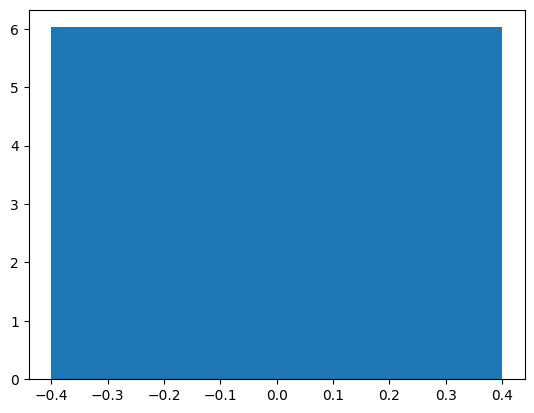

In [109]:
import matplotlib.pyplot as plt
plt.bar(range(TEST_CASE_NUM), scores)

In [110]:
M * 6 * 6 * 81 * 81

4723920